In [1]:
import xarray as xr
import flox.xarray as fx
import numpy as np
import pandas as pd
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
import oceanmixedlayers.oceanmixedlayers as oml
import oceanmixedlayers.threshold as td
import kneed
from numpy.polynomial import Chebyshev


ERROR 1: PROJ: proj_create_from_database: Open of /home.ufs/jp4778/.conda/envs/pangeo/share/proj failed


In [95]:
ds_so = xr.open_dataset('/swot/SUM05/jpope/mld_threshold.nc')

In [84]:
def mld_from_energies(prof, energies):
    """
    For an array of energies, returns an array of MLDs of the profile
    for those energies
    """
    # Initialize values
    pres = prof['PRES_INTERPOLATED'].values
    ct = prof['CT'].values
    sa = prof['SA'].values
    sig0 = prof['SIG0'].values
    
    # Mask out any NaN values
    mask = ~np.isnan(pres) & ~np.isnan(ct) & ~np.isnan(sa) & ~np.isnan(sig0)
    pres, ct, sa, sig0 = pres[mask], ct[mask], sa[mask], sig0[mask]

    # Shallowest layer thickness (negative to match sign convention)
    dp_0 = -(pres[0] - 1)
    # Center of shallowest layer just half of thickness (and positive)
    p_0 = -(dp_0/2)
    
    # Thickness array
    dp = np.array([dp_0] + list(np.full_like(pres, -2.0)))
    
    # Arrays with extrapolated surface values
    pres = np.array([p_0] + list(pres))
    ct = np.array([ct[0]] + list(ct))
    sa = np.array([sa[0]] + list(sa))
    sig0 = np.array([sig0[0]] + list(sig0))
    # Calculate MLDs
    MLDs = [oml.mld_delta_pe(pres, dp, ct, sa, coord = 'pressure',
                            energy = e).item() for e in energies]
    
    return MLDs

In [91]:
prof

<xarray.Dataset>
Dimensions:            (PRES_INTERPOLATED: 1001)
Coordinates:
  * PRES_INTERPOLATED  (PRES_INTERPOLATED) int64 0 2 4 6 ... 1994 1996 1998 2000
    N_PROF             int64 2342324
    TIME               datetime64[ns] ...
    LATITUDE           float64 ...
    LONGITUDE          float64 ...
Data variables: (12/13)
    CT                 (PRES_INTERPOLATED) float64 nan 8.093 8.099 ... nan nan
    CYCLE_NUMBER       float64 ...
    DATA_MODE          object ...
    DIRECTION          object ...
    PLATFORM_NUMBER    float64 ...
    PRES               (PRES_INTERPOLATED) float32 ...
    ...                 ...
    SA                 (PRES_INTERPOLATED) float64 nan 34.57 34.57 ... nan nan
    SIG0               (PRES_INTERPOLATED) float64 nan 26.8 26.8 ... nan nan nan
    TEMP               (PRES_INTERPOLATED) float32 ...
    sample_rate        (PRES_INTERPOLATED) float32 ...
    SPICE              (PRES_INTERPOLATED) float64 ...
    MLD_threshold      float64 ...
Attributes:
    DATA_ID:              ARGO
    DOI:                  http://doi.org/10.17882/42182
    Fetched_from:         https://data-argo.ifremer.fr
    Fetched_by:           amf2288
    Fetched_date:         2025/03/11
    Fetched_constraints:  [x=0.00/5.00; y=40.00/45.00; z=0.0/2002.0]
    Fetched_uri:          https://data-argo.ifremer.fr/dac/coriolis/6903068/6...
    Valid uris:           ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    All uris:             ['https://data-argo.ifremer.fr/dac/coriolis/6903068...
    Processing_history:   [PRES,TEMP,PSAL] real-time and adjusted/delayed var...

In [92]:
prof = ds_so.sel(N_PROF = 2342324)
energies = np.logspace(0, 2.5, 100)

[131.96170796314158,
 132.03097094046245,
 132.10106656236758,
 132.17537092558536,
 132.2541262568258,
 132.3375747822041,
 132.42604956370423,
 132.51979282598668,
 132.61913762938326,
 132.72444731203092,
 132.83605493214571,
 132.95432382553662,
 133.07967788417486,
 133.21254099844026,
 133.35333705698392,
 133.50255050396768,
 133.66072633869712,
 133.82828844331655,
 134.00535791053926,
 134.18878573863765,
 134.3831742605564,
 134.58918957582566,
 134.80749777979278,
 135.03888607720518,
 135.28408111046662,
 135.54393063001365,
 135.81934293635638,
 136.10759291673253,
 136.40904386057213,
 136.72854024083415,
 137.06705088322428,
 137.42578682823049,
 137.80608021579246,
 138.21677213945128,
 138.65653019696057,
 139.12268975345077,
 139.6165828707032,
 140.14535493187077,
 140.71433457370767,
 141.3174659536221,
 141.95547545654728,
 142.61431402175694,
 143.31214790925478,
 144.05696996135094,
 144.86767268107423,
 145.7270579683584,
 146.7681016278113,
 147.89706420972746,

In [69]:
import numpy as np

def detect_knee_angle(x, y, window= 5):
    """
    Detect knee point based on smallest angle between three consecutive points.

    Parameters
    ----------
    x : array-like
        Independent variable (e.g. energy).
    y : array-like
        Dependent variable (e.g. MLD).
    window : int
        How far before and after the center point to look (default: 1 = use i-1, i, i+1).

    Returns
    -------
    knee_idx : int
        Index of the knee point in the original data.
    angles : np.ndarray
        Array of angles (in radians) for each interior point.
    """
    x = np.asarray(x)
    y = np.asarray(y)
    n = len(x)
    angles = np.full(n, np.nan)  # initialize with NaNs

    for i in range(window, n - window):
        # Get three points: A (i-window), B (i), C (i+window)
        A = np.array([x[i - window], y[i - window]])
        B = np.array([x[i], y[i]])
        C = np.array([x[i + window], y[i + window]])

        # Vectors BA and BC
        BA = A - B
        BC = C - B

        # Angle at point B (in radians)
        cos_theta = np.dot(BA, BC) / (np.linalg.norm(BA) * np.linalg.norm(BC))
        # Clamp to [-1, 1] to avoid numerical issues
        cos_theta = np.clip(cos_theta, -1.0, 1.0)
        theta = np.arccos(cos_theta)

        angles[i] = theta

    # Knee is point with smallest angle (sharpest turn)
    knee_idx = np.nanargmin(angles)
    return knee_idx, angles


In [70]:
# Detect knee from curvature

knee_idx, angles = detect_knee_angle(energies, mld_values)

print(f"Knee detected at energy = {energies[knee_idx]}, MLD = {mld_values[knee_idx]}")


Knee detected at energy = 29.150530628251758, MLD = 162.74792564006452


In [51]:
# Detect knee from Kneedle elbow

kneedle = kneed.KneeLocator(energies, mld_values,
                  curve = 'concave',
                  direction = 'increasing',
                  interp_method = 'interp1d'
                 )

print(round(kneedle.knee, 3))

148.497


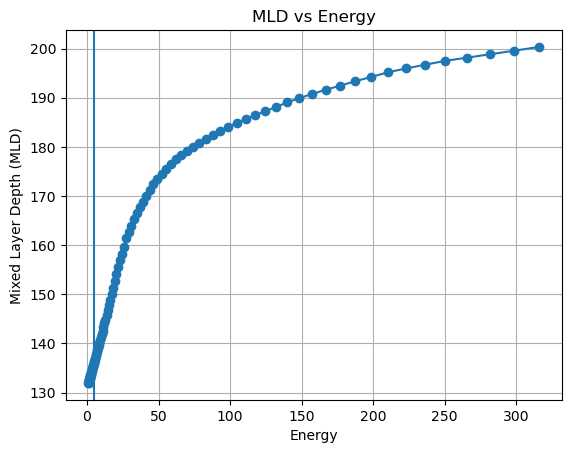

In [96]:

mask = (energies <= 10000)
plt.plot(energies[mask], np.array(mld_values)[mask], marker='o')
plt.xlabel('Energy' '')
plt.ylabel('Mixed Layer Depth (MLD)')
plt.title('MLD vs Energy')
plt.axvline(5.06)
# plt.xscale('function', functions=(np.sqrt, lambda x: x**2))

# plt.xscale('log')
plt.grid(True)
plt.show()

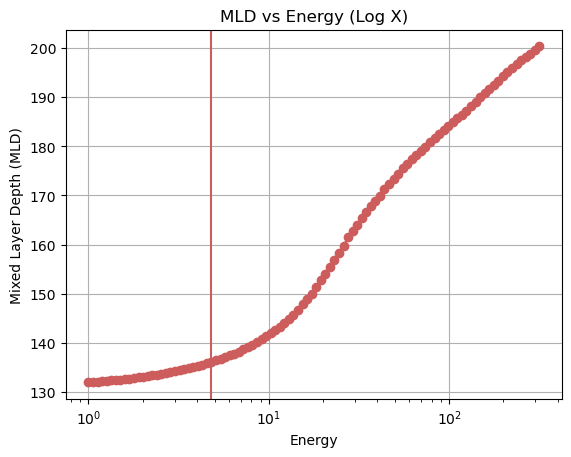

In [72]:
plt.plot(energies, mld_values, marker='o', color = 'indianred')
plt.xlabel('Energy' '')
plt.ylabel('Mixed Layer Depth (MLD)')
plt.title('MLD vs Energy (Log X)')
# plt.xscale('function', functions=(np.sqrt, lambda x: x**2))
plt.axvline(4.81, color = 'indianred')
plt.xscale('log')
plt.grid(True)
plt.show()

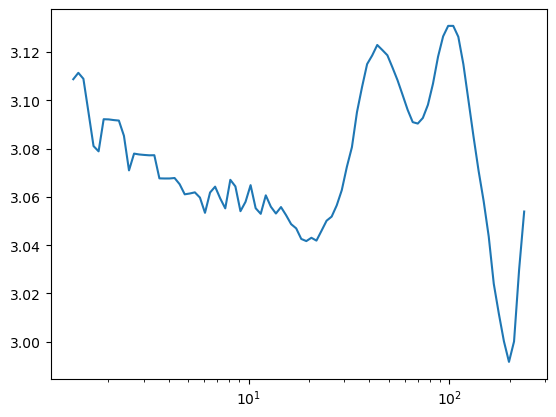

In [57]:
plt.plot(energies, angles)
plt.xscale('log')

In [16]:
ds_subset = ds_so
energies = np.logspace(0, 2.5, 100)

In [18]:
# Select profiles with valid data at 1000 dbar
sig0_at_10 = ds_subset['SIG0'].sel(PRES_INTERPOLATED=10, method='nearest')
valid_mask = ~np.isnan(sig0_at_10)
valid_indices = np.where(valid_mask.values)[0]

# Filter ds_subset to retain only those profiles
ds_filtered = ds_subset.isel(N_PROF=valid_indices)

# Select only data at or deeper than 10m
depth_mask = (ds_filtered['PRES_INTERPOLATED'] >= 10) & (ds_filtered['PRES_INTERPOLATED'] <= 1000)
ds_filtered = ds_filtered.where(depth_mask, drop = True)

In [ ]:
ds_filtered = ds_filtered.sel('N_PROF' = 2342324)

In [1126]:
diff = y_norm - x_norm

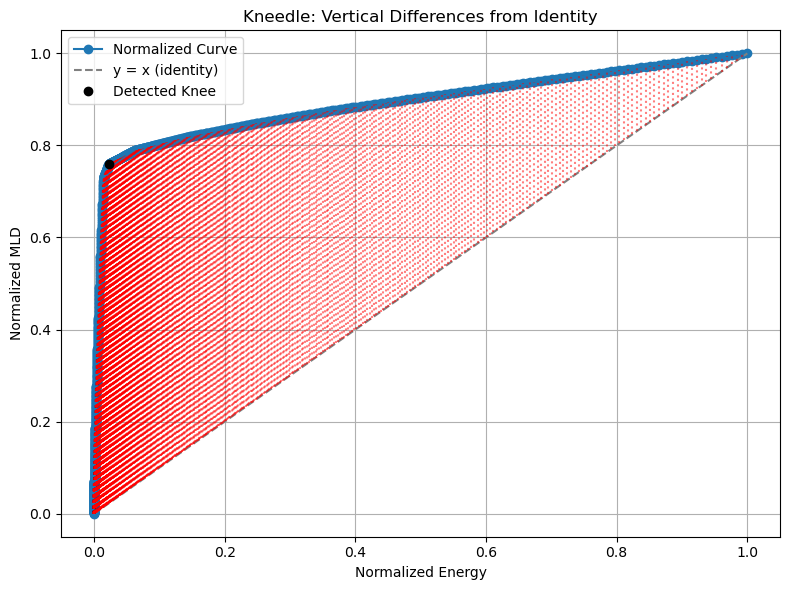

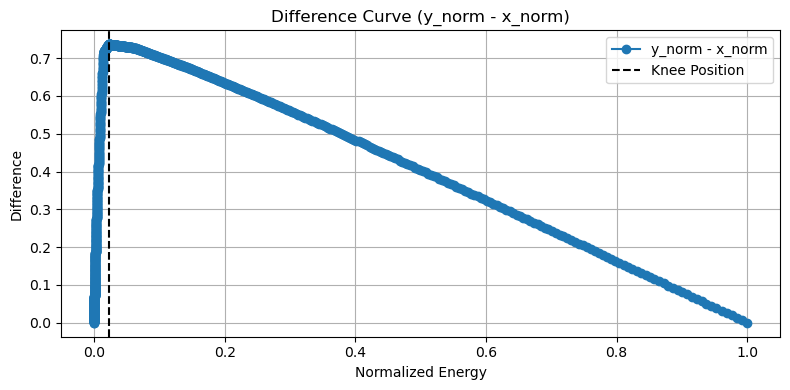

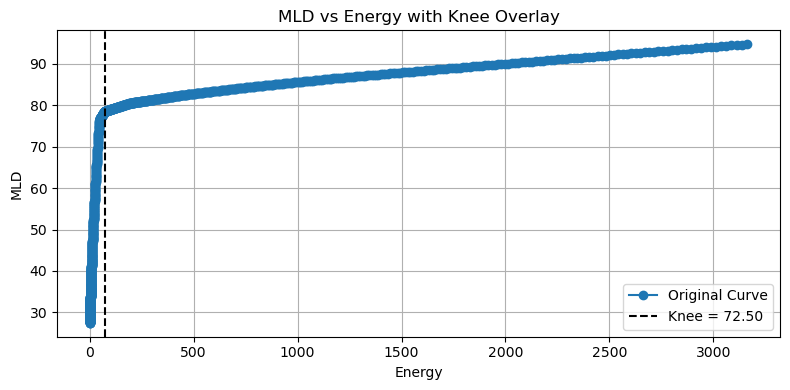

In [1184]:
import numpy as np
import matplotlib.pyplot as plt
from kneed import KneeLocator

# --- Your data ---
x = np.array(energies)
y = np.array(mld_values)

# --- Normalize ---
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

# --- Run KneeLocator ---
kneedle = KneeLocator(x, y, curve='concave', direction='increasing')

# --- Vertical differences ---
diff = y_norm - x_norm

# --- Index of the knee ---
if kneedle.knee is not None:
    knee_idx = np.where(x == kneedle.knee)[0][0]
else:
    knee_idx = None

# === 1. Normalized plot with identity ===
plt.figure(figsize=(8, 6))
plt.plot(x_norm, y_norm, label='Normalized Curve', marker='o')
plt.plot(x_norm, x_norm, '--', label='y = x (identity)', color='gray')
for xi, yi in zip(x_norm, y_norm):
    plt.vlines(xi, xi, yi, color='red', linestyle=':', alpha=0.5)
if knee_idx is not None:
    plt.plot(x_norm[knee_idx], y_norm[knee_idx], 'ko', label='Detected Knee')
plt.xlabel('Normalized Energy')
plt.ylabel('Normalized MLD')
plt.title('Kneedle: Vertical Differences from Identity')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Difference curve ===
plt.figure(figsize=(8, 4))
plt.plot(x_norm, diff, marker='o', label='y_norm - x_norm')
if knee_idx is not None:
    plt.axvline(x_norm[knee_idx], color='k', linestyle='--', label='Knee Position')
plt.xlabel('Normalized Energy')
plt.ylabel('Difference')
plt.title('Difference Curve (y_norm - x_norm)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 3. Original scale plot with knee ===
plt.figure(figsize=(8, 4))
plt.plot(x, y, marker='o', label='Original Curve')
if knee_idx is not None:
    plt.axvline(x[knee_idx], color='k', linestyle='--', label=f'Knee = {x[knee_idx]:.2f}')
plt.xlabel('Energy')
plt.ylabel('MLD')
plt.title('MLD vs Energy with Knee Overlay')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


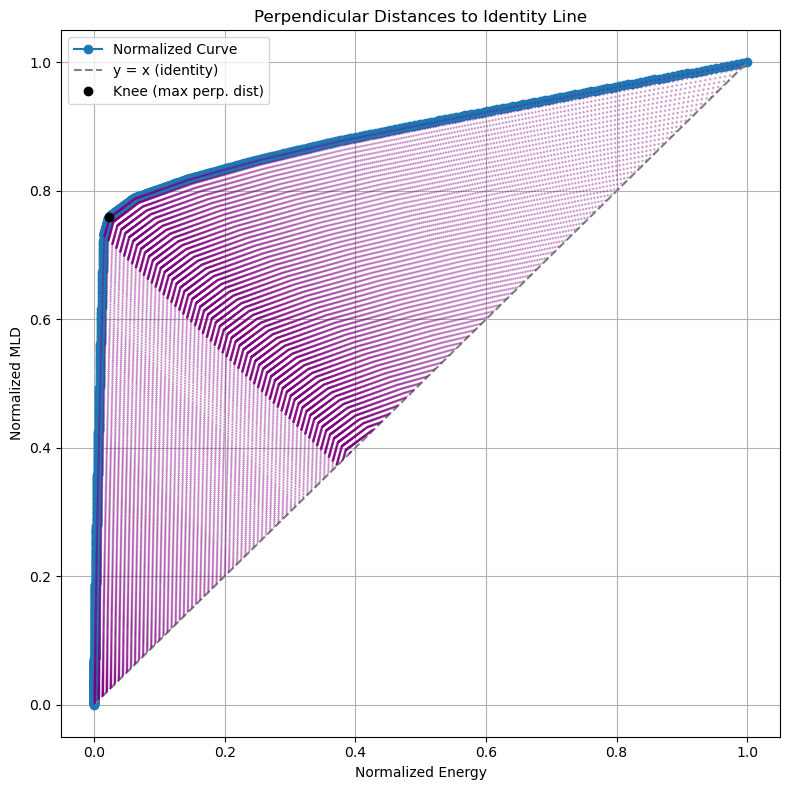

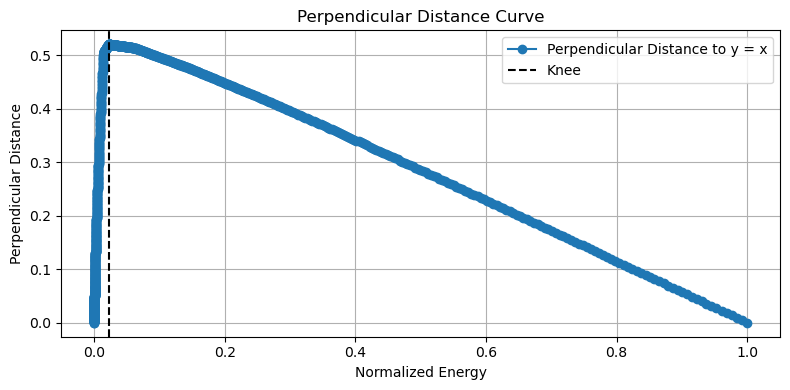

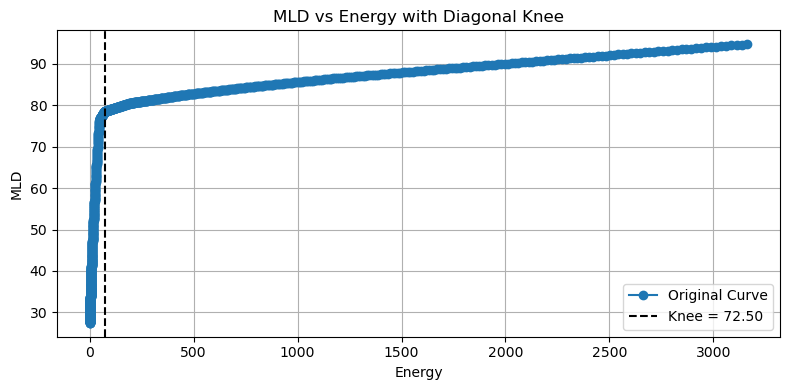

In [1185]:
import numpy as np
import matplotlib.pyplot as plt

# Your data
x = np.array(energies)
y = np.array(mld_values)

# Normalize
x_norm = (x - x.min()) / (x.max() - x.min())
y_norm = (y - y.min()) / (y.max() - y.min())

# Compute perpendicular distance to y = x
distance = np.abs(y_norm - x_norm) / np.sqrt(2)
knee_idx = np.argmax(distance)

# === 1. Plot with actual perpendicular projections ===
plt.figure(figsize=(8, 8))
plt.plot(x_norm, y_norm, label='Normalized Curve', marker='o')
plt.plot(x_norm, x_norm, '--', label='y = x (identity)', color='gray')

# Draw true perpendicular arrows to y = x
for xi, yi in zip(x_norm, y_norm):
    proj = (xi + yi) / 2
    plt.plot([xi, proj], [yi, proj], color='purple', alpha=0.4, linestyle=':')

# Mark knee
plt.plot(x_norm[knee_idx], y_norm[knee_idx], 'ko', label='Knee (max perp. dist)')
plt.xlabel('Normalized Energy')
plt.ylabel('Normalized MLD')
plt.title('Perpendicular Distances to Identity Line')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 2. Distance curve ===
plt.figure(figsize=(8, 4))
plt.plot(x_norm, distance, marker='o', label='Perpendicular Distance to y = x')
plt.axvline(x_norm[knee_idx], color='k', linestyle='--', label='Knee')
plt.xlabel('Normalized Energy')
plt.ylabel('Perpendicular Distance')
plt.title('Perpendicular Distance Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# === 3. Original scale plot with knee ===
plt.figure(figsize=(8, 4))
plt.plot(x, y, marker='o', label='Original Curve')
plt.axvline(x[knee_idx], color='k', linestyle='--', label=f'Knee = {x[knee_idx]:.2f}')
plt.xlabel('Energy')
plt.ylabel('MLD')
plt.title('MLD vs Energy with Diagonal Knee')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [1086]:
# Get polynomial fit of data
degree = 10
coeffs = np.polyfit(energies, mld_values, deg = degree)
poly_fit = np.poly1d(coeffs)
second_deriv = poly_fit.deriv(m = 1)

In [1220]:
# Fit points to curve
x_fit = np.linspace(min(energies), max(energies), 1000)


y_poly = poly_fit(x_smooth)
y_poly_d1 = poly_fit.deriv(m =1)(x_fit)
y_poly_d2 = poly_fit.deriv(m = 2)(x_fit)

spline = UnivariateSpline(energies, mld_values, s=1, k=5)
y_spline = spline(x_fit)
y_spline_1d = spline.derivative(n = 1)(x_fit)
y_spline_2d = spline.derivative(n = 2)(x_fit)

In [1221]:
cheb_fit = Chebyshev.fit(energies, mld_values, deg = 8)
cheb_d1 = cheb_fit.deriv(1)
cheb_d2 = cheb_fit.deriv(2)

In [1222]:
y_cheb = cheb_fit(x_fit)
y_cheb_d1 = cheb_d1(x_fit)
y_cheb_d2 = cheb_d2(x_fit)

In [1223]:
kneedle = kneed.KneeLocator(energies, mld_values,
                  curve = 'concave',
                  direction = 'increasing',
                  interp_method = 'interp1d'
                 )

print(round(kneedle.knee, 3))

72.337


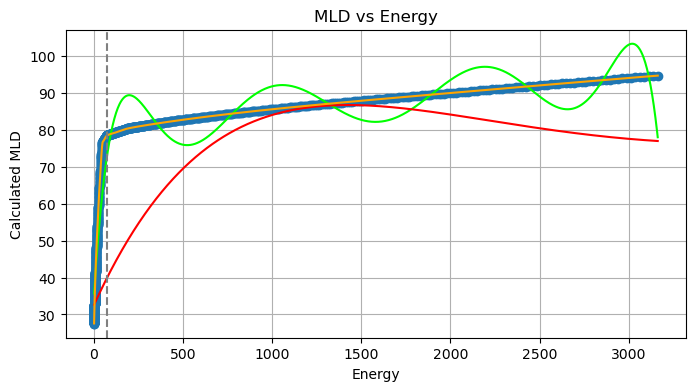

In [1105]:
plt.figure(figsize=(8, 4))
plt.plot(energies, mld_values, marker = 'o')
plt.plot(x_fit, y_cheb, color = 'lime')
plt.plot(x_fit, y_poly, color = 'red')
plt.plot(x_fit, y_spline, color = 'orange')
plt.xlabel("Energy")
plt.ylabel("Calculated MLD")
plt.title("MLD vs Energy")
plt.axvline(kneedle.knee, color = 'grey', linestyle ='--')
plt.grid(True)
plt.show()


In [1098]:
def log_model (x, a, b, c):
    return a * np.log(b * x + c)

In [ ]:
p0 = (10, 0.01, 1)

# Fit the model
params, _ = curve_fit(log_model, energy_vals, mld_vals, p0=p0)

# Evaluate the fit
x_fit = np.linspace(min(energy_vals), max(energy_vals), 300)
y_fit = log_model(x_fit, *params)

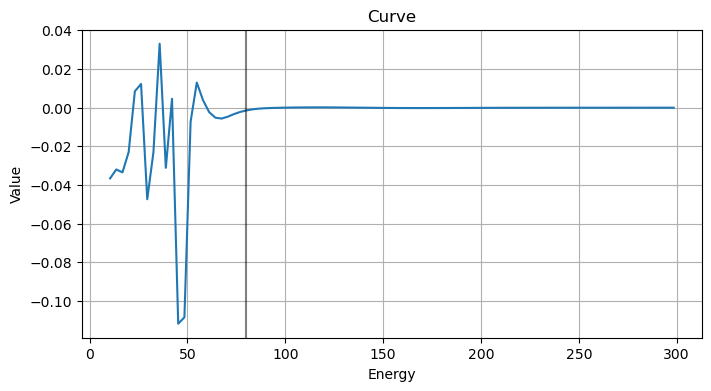

In [1103]:
mask = (x_fit >= 10) & (x_fit <= 300)
plt.figure(figsize=(8, 4))
plt.plot(x_fit[mask], y_spline_2d[mask])
plt.xlabel("Energy")
plt.ylabel("Value")
plt.title("Curve")
plt.axvline(kneedle.knee, color = 'k', alpha = 0.5)

plt.grid(True)
plt.show()


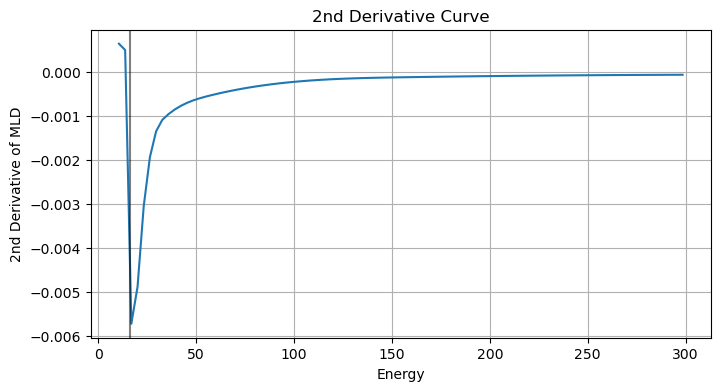

In [993]:
mask = (x_fit >= 10) & (x_fit <= 300)
plt.figure(figsize=(8, 4))
# plt.plot(x_fit, spline_1st_deriv)
plt.plot(x_fit[mask], spline_2nd_deriv[mask])
plt.xlabel("Energy")
plt.ylabel("2nd Derivative of MLD")
plt.title("2nd Derivative Curve")
plt.axvline(16, color = 'k', alpha = 0.5)

plt.grid(True)
plt.show()


In [1099]:
kneedle = kneed.KneeLocator(x_fit, spline_1st_deriv,
                  curve = 'convex',
                  direction = 'decreasing',
                  interp_method = 'interp1d', S = 50.0,
                 )

print(round(kneedle.knee, 3))

80.111


In [476]:
mld_values

[27.487390770833915,
 27.96523213592252,
 28.502529496500998,
 28.976789024202382,
 29.33892885091981,
 29.746206566959845,
 30.204264232538662,
 30.719411200136282,
 31.251605039560168,
 31.83937081017996,
 32.500544880228446,
 33.23209314135758,
 34.04578469334799,
 34.956300494888005,
 35.95684451029713,
 37.052026338412766,
 38.19161157038696,
 39.36322333218355,
 40.57972255686835,
 41.92191689279605,
 43.41043075800657,
 45.05351190192687,
 46.85091435552276,
 48.70362896544629,
 50.72885847650484,
 52.8079394045032,
 55.06001340846022,
 57.50424487692034,
 60.401474984154355,
 63.52432841511819,
 66.62287499573902,
 70.11251274029681,
 73.68993115297836,
 76.6120074691932,
 77.08967200573501,
 77.6269600524019,
 78.23108920176227,
 78.60259298345143,
 78.75788000576401,
 78.93251334977609,
 79.12891885521492,
 79.34979525991571,
 79.59820516650075,
 79.877575037405,
 80.19172551222164,
 80.52737154928444,
 80.7165201101297,
 80.92922492169917,
 81.1684266837931,
 81.437460199886